## <p style="background-color:#9d4f8c; font-family:newtimeroman; color:#FFF9ED; font-size:175%; text-align:center; border-radius:10px 10px;">PART- 03- OUTLIER ANALYSIS</p>

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv("../data/processed/missings_filled.csv")

In [2]:
df.head(3).T

,0,1,2
make_model,Audi A1,Audi A1,Audi A1
body_type,Sedans,Sedans,Sedans
price,15770,14500,14640
vat,VAT deductible,Price negotiable,VAT deductible
km,56013.0,80000.0,83450.0
hp,66.0,141.0,85.0
type,Used,Used,Used
inspection_new,Yes,No,No
warranty,4.0,0.0,99.0
body_color,Black,Red,Black


In [3]:
#Price

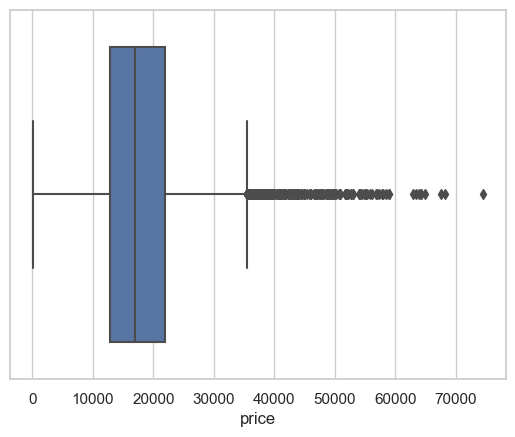

In [4]:
sns.set_theme(style="whitegrid")
ax = sns.boxplot(x=df["price"])

In [5]:
df.describe()

,price,km,hp,warranty,nr_of_doors,nr_of_seats,displacement,cylinders,weight,co2_emission,gears,registration_year,age,cons_comb,prev_owner
count,15919.000000,15919.000000,15919.000000,15919.000000,15919.000000,15919.000000,15919.000000,15919.000000,15919.000000,15919.000000,15919.000000,15919.000000,15919.000000,15919.000000,15919.000000
mean,18019.896727,32082.290954,88.374144,19.035178,4.660657,4.952258,1425.261574,3.786733,1343.429927,122.415039,5.939820,2017.610214,1.389472,4.876227,0.955211
std,7386.169409,36975.782301,26.843513,35.887723,0.642198,0.476599,330.882580,0.418128,210.651964,248.559628,0.791983,1.121257,1.121282,1.557852,0.206847
min,13.000000,0.000000,1.000000,0.000000,1.000000,2.000000,1.000000,1.000000,1.000000,0.000000,1.000000,2016.000000,0.000000,0.000000,0.000000
25%,12850.000000,1906.500000,66.000000,0.000000,4.000000,5.000000,1229.000000,4.000000,1163.000000,104.000000,5.000000,2017.000000,0.000000,4.100000,1.000000
50%,16900.000000,20407.000000,85.000000,6.000000,5.000000,5.000000,1461.000000,4.000000,1279.000000,117.000000,6.000000,2018.000000,1.000000,4.800000,1.000000
75%,21900.000000,46898.500000,101.000000,12.000000,5.000000,5.000000,1598.000000,4.000000,1485.000000,128.000000,6.000000,2019.000000,2.000000,5.400000,1.000000
max,74600.000000,317000.000000,294.000000,199.000000,7.000000,7.000000,16000.000000,8.000000,2471.000000,14457.000000,50.000000,2019.000000,3.000000,55.000000,1.000000


In [6]:
df.drop((df[df.price < 4000].price.index), axis=0, inplace=True)

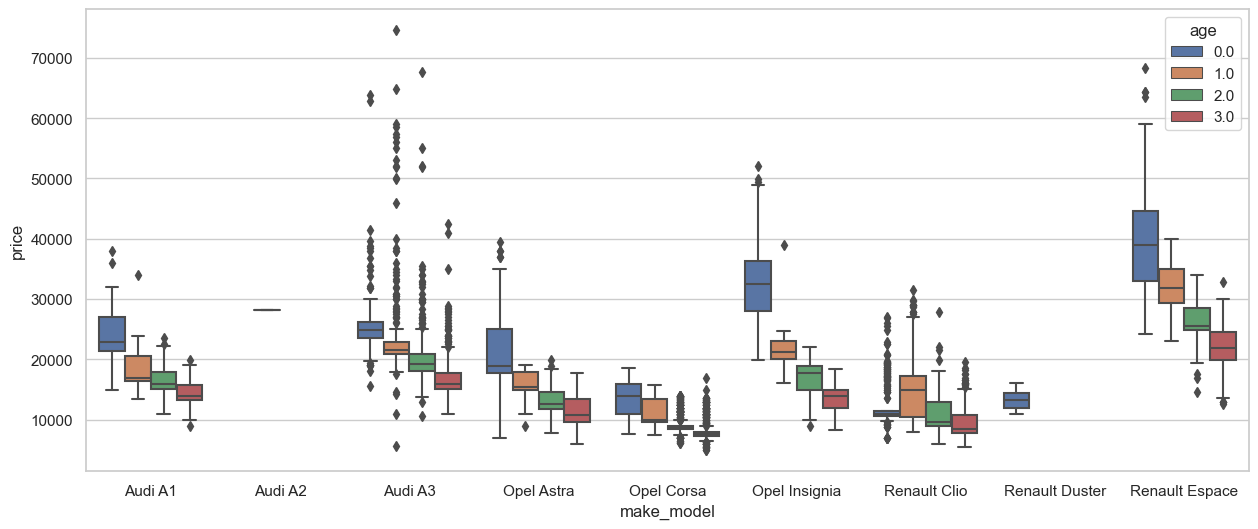

In [7]:
plt.figure(figsize=(15,6))
sns.boxplot(y='price',data=df, x='make_model', hue='age');

In [8]:
df[(df['make_model']=='Renault Espace')].groupby(['body_type', 'age']).price.max()

body_type      age
Compact        0.0    43000
               2.0    23990
               3.0    21900
Coupe          0.0    34140
               1.0    26994
Off-Road       1.0    27850
               2.0    32900
               3.0    14900
Other          0.0    42681
               1.0    34000
               2.0    27900
               3.0    32900
Sedans         0.0    48498
               1.0    36900
               2.0    23990
               3.0    25900
Station wagon  0.0    52990
               1.0    39990
               2.0    33900
               3.0    27500
Transporter    0.0    32700
               1.0    31000
               2.0    28300
               3.0    30000
Van            0.0    68320
               1.0    38990
               2.0    33800
               3.0    27900
Name: price, dtype: int64

In [9]:
# km

<AxesSubplot:xlabel='age', ylabel='km'>

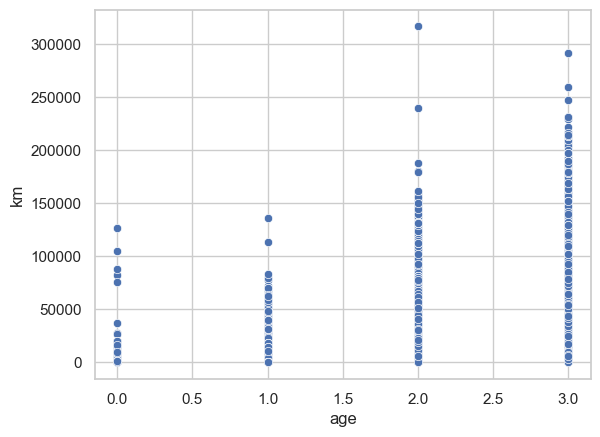

In [10]:
sns.scatterplot(data=df, x= 'age', y='km')

In [11]:
# prev_owner

In [12]:
df.prev_owner.value_counts(dropna= False)

1.0    15202
0.0      713
Name: prev_owner, dtype: int64

In [13]:
# hp

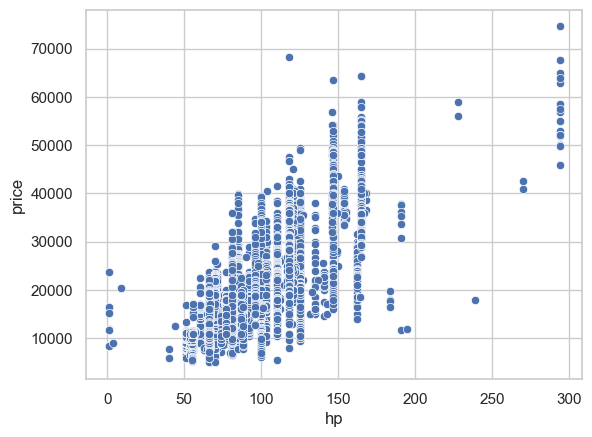

In [14]:
sns.scatterplot(data=df, x="hp", y="price");

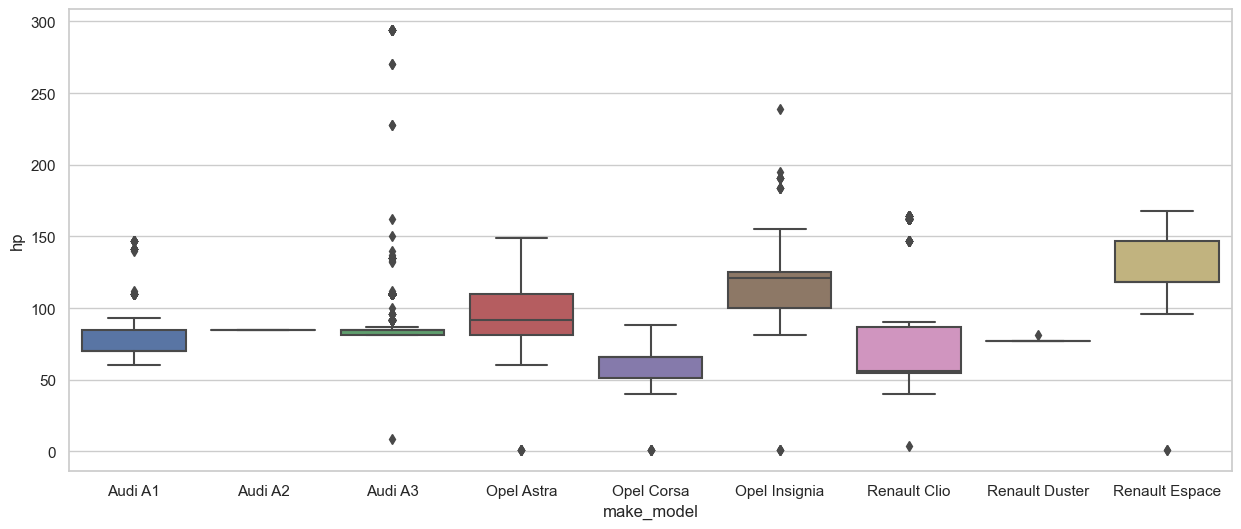

In [15]:
plt.figure(figsize=(15,6))
sns.boxplot(y='hp',data=df, x='make_model');

In [16]:
df[df['hp'] < 50].hp.value_counts(dropna=False)

1.0     20
40.0     2
9.0      1
44.0     1
4.0      1
Name: hp, dtype: int64

In [17]:
# hp values less than 50 were converted to null values.
df.loc[df['hp']<50,'hp'] = np.nan

In [18]:
#Then null values were refilled according to 
#the columns 'make_model','body_type','displacement'

In [19]:
mode_hp = df.groupby(['make_model','body_type','displacement'])['hp']\
              .transform(lambda x: x.mode()[0] if list(x.mode()) != [] else np.nan)

df["hp"] = df["hp"].fillna(mode_hp)

mode_hp1 = df.groupby(['make_model','displacement'])['hp']\
              .transform(lambda x: x.mode()[0] if list(x.mode()) != [] else np.nan)

df["hp"] = df["hp"].fillna(mode_hp1)

mode_hp2 = df.groupby(['make_model','body_type'])['hp']\
              .transform(lambda x: x.mode()[0] if list(x.mode()) != [] else np.nan)

df["hp"] = df["hp"].fillna(mode_hp2)

In [20]:
# warranty

In [21]:
df['warranty'].value_counts(dropna=False)

0.0      6760
12.0     2595
6.0      2394
24.0     1118
4.0       530
         ... 
131.0       1
15.0        1
155.0       1
7.0         1
161.0       1
Name: warranty, Length: 124, dtype: int64

In [22]:
df.columns

Index(['make_model', 'body_type', 'price', 'vat', 'km', 'hp', 'type',
       'inspection_new', 'warranty', 'body_color', 'paint_type', 'nr_of_doors',
       'nr_of_seats', 'gearing_type', 'displacement', 'cylinders', 'weight',
       'drive_chain', 'fuel', 'co2_emission', 'emission_class',
       'comfort_and_convenience', 'entertainment_and_media', 'extras',
       'safety_and_security', 'gears', 'registration_year', 'age',
       'upholstery_type', 'cons_comb', 'prev_owner'],
      dtype='object')

In [23]:
df.body_color.value_counts()

Black     3941
Grey      3838
White     3468
Silver    1647
Blue      1431
Red        957
Brown      289
Green      158
Beige      108
Yellow      51
Violet      18
Bronze       6
Orange       3
Name: body_color, dtype: int64

In [24]:
df.nr_of_doors.value_counts()

5.0    11784
4.0     3079
3.0      831
2.0      219
1.0        1
7.0        1
Name: nr_of_doors, dtype: int64

In [25]:
df[df.nr_of_doors == 1]

,make_model,body_type,price,vat,km,hp,type,inspection_new,warranty,body_color,...,comfort_and_convenience,entertainment_and_media,extras,safety_and_security,gears,registration_year,age,upholstery_type,cons_comb,prev_owner
13782,Renault Clio,Compact,8500,VAT deductible,41493.0,55.0,Used,No,12.0,White,...,NaN,NaN,NaN,NaN,5.0,2016.0,3.0,NaN,3.3,1.0


In [26]:
df.loc[(df['make_model'] == 'Renault Clio') & (df['body_type'] == 'Compact'), ['nr_of_doors']].value_counts()

nr_of_doors
5.0            313
4.0            170
1.0              1
dtype: int64

In [27]:
df.loc[df.nr_of_doors == 1,'nr_of_doors'] = 5

In [28]:
df.nr_of_doors.value_counts()

5.0    11785
4.0     3079
3.0      831
2.0      219
7.0        1
Name: nr_of_doors, dtype: int64

In [29]:
df[df.nr_of_doors == 7]

,make_model,body_type,price,vat,km,hp,type,inspection_new,warranty,body_color,...,comfort_and_convenience,entertainment_and_media,extras,safety_and_security,gears,registration_year,age,upholstery_type,cons_comb,prev_owner
15202,Renault Espace,Van,21600,Price negotiable,78000.0,118.0,Used,No,0.0,Brown,...,"'Air conditioning', 'Armrest', 'Automatic clim...","'Bluetooth', 'Digital radio', 'MP3', 'On-board...","Alloy wheels,Touch screen","ABS,Blind spot monitor,Central door lock,Dayti...",6.0,2016.0,3.0,Full leather,4.6,1.0


In [30]:
df.loc[df.nr_of_doors == 4,'nr_of_doors'] = 5

In [31]:
df.loc[df.nr_of_doors == 7,'nr_of_doors'] = 5

In [32]:
df.loc[df.nr_of_doors == 2,'nr_of_doors'] = 3

In [33]:
df.nr_of_doors.value_counts()

5.0    14865
3.0     1050
Name: nr_of_doors, dtype: int64

In [34]:
df.nr_of_seats.value_counts()

5.0    14304
4.0     1127
7.0      362
2.0      119
6.0        2
3.0        1
Name: nr_of_seats, dtype: int64

In [35]:
df.loc[df.nr_of_seats == 3]

,make_model,body_type,price,vat,km,hp,type,inspection_new,warranty,body_color,...,comfort_and_convenience,entertainment_and_media,extras,safety_and_security,gears,registration_year,age,upholstery_type,cons_comb,prev_owner
1636,Audi A1,Compact,23090,VAT undeductible,9821.0,141.0,Used,Yes,4.0,Black,...,"'Air conditioning', 'Armrest', 'Automatic clim...","'Bluetooth', 'CD player', 'Digital radio', 'Ha...","Alloy wheels,Catalytic Converter,Sport package...","ABS,Central door lock,Daytime running lights,D...",7.0,2018.0,1.0,Part leather,5.8,1.0


In [36]:
# nr_of_seats
df.nr_of_seats.value_counts()

5.0    14304
4.0     1127
7.0      362
2.0      119
6.0        2
3.0        1
Name: nr_of_seats, dtype: int64

In [37]:
df.loc[df.nr_of_seats == 3]

,make_model,body_type,price,vat,km,hp,type,inspection_new,warranty,body_color,...,comfort_and_convenience,entertainment_and_media,extras,safety_and_security,gears,registration_year,age,upholstery_type,cons_comb,prev_owner
1636,Audi A1,Compact,23090,VAT undeductible,9821.0,141.0,Used,Yes,4.0,Black,...,"'Air conditioning', 'Armrest', 'Automatic clim...","'Bluetooth', 'CD player', 'Digital radio', 'Ha...","Alloy wheels,Catalytic Converter,Sport package...","ABS,Central door lock,Daytime running lights,D...",7.0,2018.0,1.0,Part leather,5.8,1.0


In [38]:
df.loc[df.nr_of_seats == 3,'nr_of_seats'] = 4

In [39]:
df.loc[df.nr_of_seats == 6]

,make_model,body_type,price,vat,km,hp,type,inspection_new,warranty,body_color,...,comfort_and_convenience,entertainment_and_media,extras,safety_and_security,gears,registration_year,age,upholstery_type,cons_comb,prev_owner
582,Audi A1,Compact,13500,VAT deductible,100000.000000,70.0,Used,No,12.0,White,...,'Air conditioning','On-board computer',Alloy wheels,ABS,5.0,2017.0,2.0,NaN,4.9,1.0
15890,Renault Espace,Station wagon,42490,VAT deductible,1647.362609,147.0,New,No,0.0,Black,...,"'Air conditioning', 'Armrest', 'Automatic clim...","'Bluetooth', 'Hands-free equipment', 'On-board...","Alloy wheels,Touch screen","ABS,Blind spot monitor,Central door lock,Dayti...",6.0,2019.0,0.0,Cloth,5.7,1.0


In [40]:
df.loc[582,'nr_of_seats'] = 4

In [41]:
# displacement

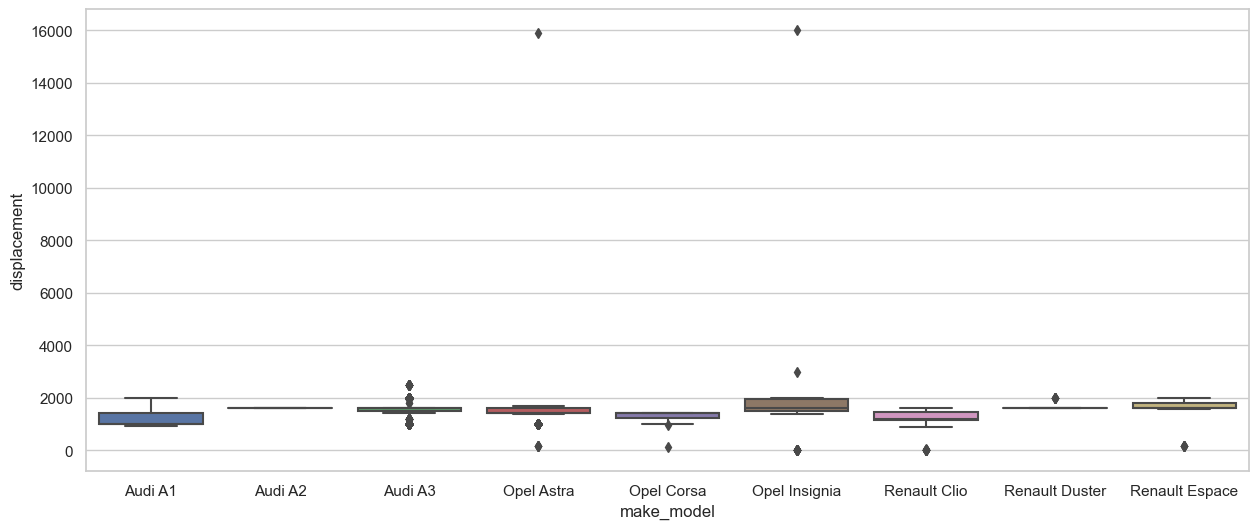

In [42]:
plt.figure(figsize=(15,6))
sns.boxplot(y='displacement',data=df, x='make_model');

In [43]:
df.loc[df.displacement>5000, 'displacement'] = np.nan

In [44]:
df.loc[df.displacement<600, 'displacement'] = np.nan

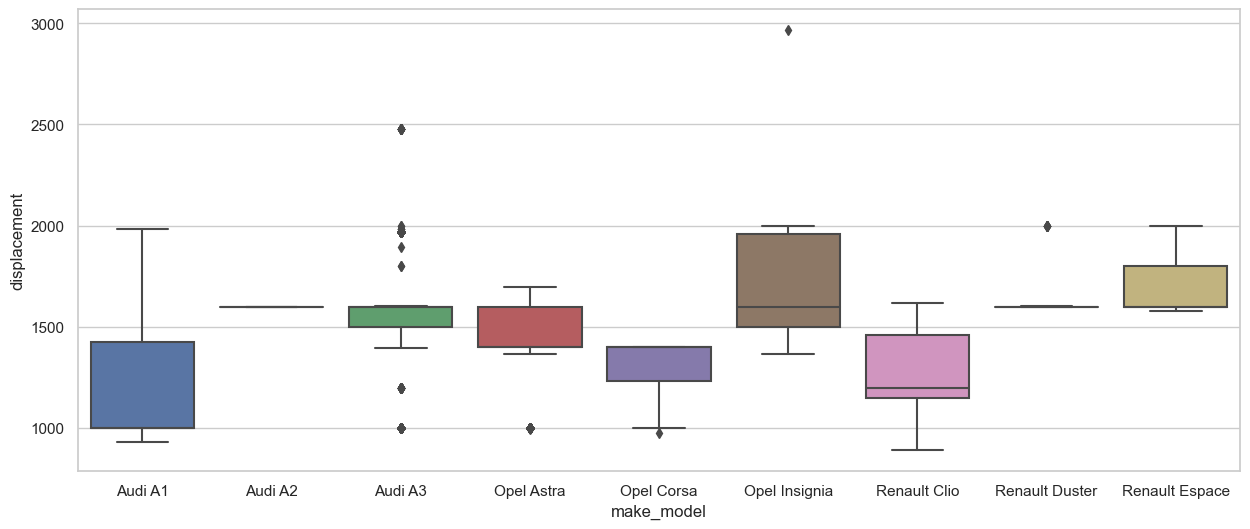

In [45]:
plt.figure(figsize=(15,6))
sns.boxplot(y='displacement',data=df, x='make_model');

In [46]:
mode_disp = df.groupby(['make_model','body_type','hp'])['displacement']\
              .transform(lambda x: x.mode()[0] if list(x.mode()) != [] else np.nan)

In [47]:
df["displacement"] = df["displacement"].fillna(mode_disp)

In [48]:
# cylinders

In [49]:
df["cylinders"].value_counts()

4.0    12463
3.0     3422
5.0       22
6.0        3
8.0        2
2.0        2
1.0        1
Name: cylinders, dtype: int64

In [50]:
df.loc[df["cylinders"]<3,'make_model':'displacement']

,make_model,body_type,price,vat,km,hp,type,inspection_new,warranty,body_color,paint_type,nr_of_doors,nr_of_seats,gearing_type,displacement
9956,Opel Corsa,Compact,16625,VAT deductible,100.0,66.0,Pre-registered,No,6.0,Black,Metallic,3.0,5.0,Automatic,1398.0
11342,Opel Insignia,Station wagon,21900,VAT deductible,13600.0,100.0,Employee's car,No,0.0,Grey,Metallic,5.0,5.0,Automatic,1598.0
15835,Renault Espace,Van,47590,VAT deductible,6000.0,147.0,Employee's car,No,0.0,Black,Metallic,5.0,7.0,Automatic,1997.0


In [51]:
df[df.make_model == 'Opel Insignia'].cylinders.value_counts()

4.0    2594
6.0       3
2.0       1
Name: cylinders, dtype: int64

In [52]:
df.loc[df["cylinders"]<3,'cylinders'] = 4

In [53]:
df.loc[df["cylinders"]>5,'make_model':'cylinders']

,make_model,body_type,price,vat,km,hp,type,inspection_new,warranty,body_color,paint_type,nr_of_doors,nr_of_seats,gearing_type,displacement,cylinders
535,Audi A1,Compact,12990,VAT undeductible,41200.0,70.0,Used,Yes,4.0,Silver,Metallic,5.0,5.0,Manual,999.0,8.0
10771,Opel Insignia,Station wagon,12000,Price negotiable,185000.0,100.0,Used,No,0.0,White,Metallic,5.0,5.0,Automatic,2967.0,6.0
10826,Opel Insignia,Station wagon,12500,Price negotiable,77500.0,100.0,Used,No,0.0,Grey,Metallic,5.0,5.0,Automatic,1598.0,6.0
12897,Opel Insignia,Sedans,26500,VAT deductible,5.0,100.0,Used,No,12.0,Grey,Uni/basic,5.0,5.0,Manual,1600.0,6.0
15055,Renault Espace,Van,24990,VAT undeductible,47423.0,117.0,Used,No,3.0,Black,Metallic,5.0,5.0,Automatic,1598.0,8.0


In [54]:
# weight
# weight values less than 600 were converted

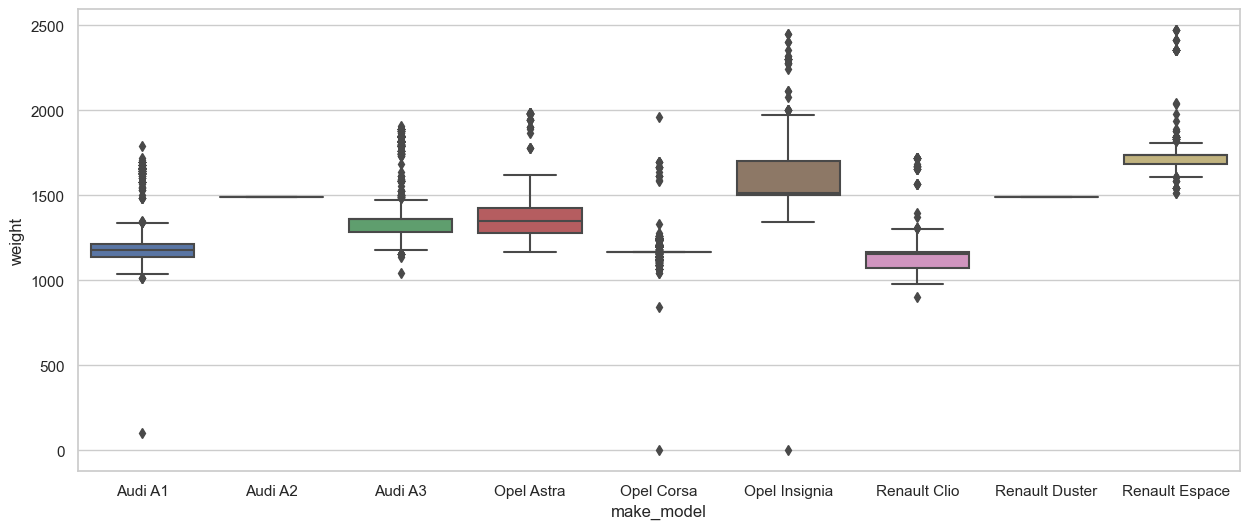

In [55]:
plt.figure(figsize=(15,6))
sns.boxplot(y='weight',data=df, x='make_model');

In [56]:
df[df.weight<600]

,make_model,body_type,price,vat,km,hp,type,inspection_new,warranty,body_color,...,comfort_and_convenience,entertainment_and_media,extras,safety_and_security,gears,registration_year,age,upholstery_type,cons_comb,prev_owner
1143,Audi A1,Compact,19229,VAT deductible,8263.0,70.0,Used,Yes,36.0,Beige,...,"'Air conditioning', 'Armrest', 'Automatic clim...","'Bluetooth', 'CD player', 'Hands-free equipmen...","Alloy wheels,Catalytic Converter,Sport seats,S...","ABS,Central door lock,Daytime running lights,D...",7.0,2018.0,1.0,Cloth,4.6,1.0
8355,Opel Corsa,Compact,12945,VAT undeductible,2015.0,66.0,Used,Yes,4.0,Silver,...,"'Air conditioning', 'Electrical side mirrors',...",'Radio',Catalytic Converter,"ABS,Central door lock,Daytime running lights,D...",5.0,2018.0,1.0,Cloth,4.8,1.0
12779,Opel Insignia,Station wagon,39299,VAT deductible,10.0,121.0,New,No,0.0,Black,...,"'Heated steering wheel', 'Hill Holder', 'Park ...",NaN,NaN,"Fog lights,Lane departure warning system",6.0,2019.0,0.0,Cloth,6.0,1.0


In [57]:
df[df['make_model'] == 'Audi A1']['weight'].mean()

1202.9491201224178

In [58]:
df.loc[1143,'weight'] = 1200

In [59]:
df[df['make_model'] == 'Opel Corsa']['weight'].mean()

1169.9864620938629

In [60]:
df.loc[8355,'weight'] = 1169

In [61]:
df[df['make_model'] == 'Opel Insignia']['weight'].mean()

1588.4661277906082

In [62]:
df.loc[12779, 'weight']= 1600

In [63]:
df[df.weight<500]

,make_model,body_type,price,vat,km,hp,type,inspection_new,warranty,body_color,...,comfort_and_convenience,entertainment_and_media,extras,safety_and_security,gears,registration_year,age,upholstery_type,cons_comb,prev_owner


In [64]:
# drive_chain
df.drive_chain.value_counts()

front    15707
4WD        204
rear         4
Name: drive_chain, dtype: int64

In [65]:
# co2_emission

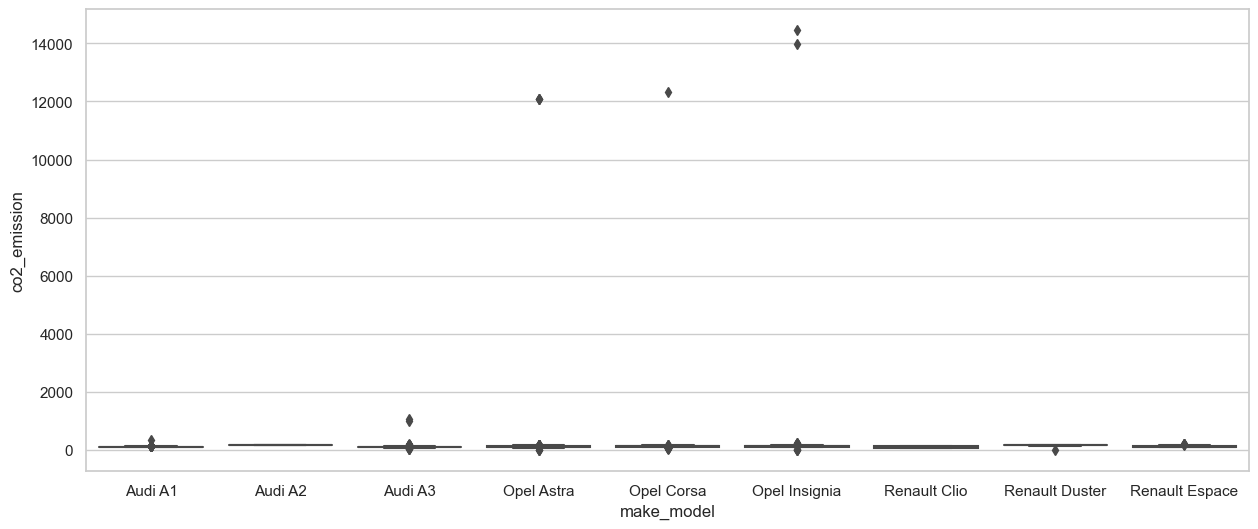

In [66]:
plt.figure(figsize=(15,6))
sns.boxplot(y='co2_emission',data=df, x='make_model');

In [67]:
df.loc[df.co2_emission>300,'co2_emission'] = np.nan

In [68]:
df.loc[df.co2_emission<70,'co2_emission'] = np.nan

In [69]:
mode_CO2 = df.groupby(['make_model','displacement'])['co2_emission']\
              .transform(lambda x: x.mode()[0] if list(x.mode()) != [] else np.nan)

In [70]:
df['co2_emission'] = df['co2_emission'].fillna(mode_CO2)

In [71]:
mode_CO2_1 = df.groupby(['make_model'])['co2_emission']\
              .transform(lambda x: x.mode()[0] if list(x.mode()) != [] else np.nan)

In [72]:
df['co2_emission'] = df['co2_emission'].fillna(mode_CO2_1)

In [73]:
mode_CO2_2 = df.groupby(['body_type'])['co2_emission']\
              .transform(lambda x: x.mode()[0] if list(x.mode()) != [] else np.nan)

In [74]:
df['co2_emission'] = df['co2_emission'].fillna(mode_CO2_2)

In [75]:
df['co2_emission'].isnull().sum()

0

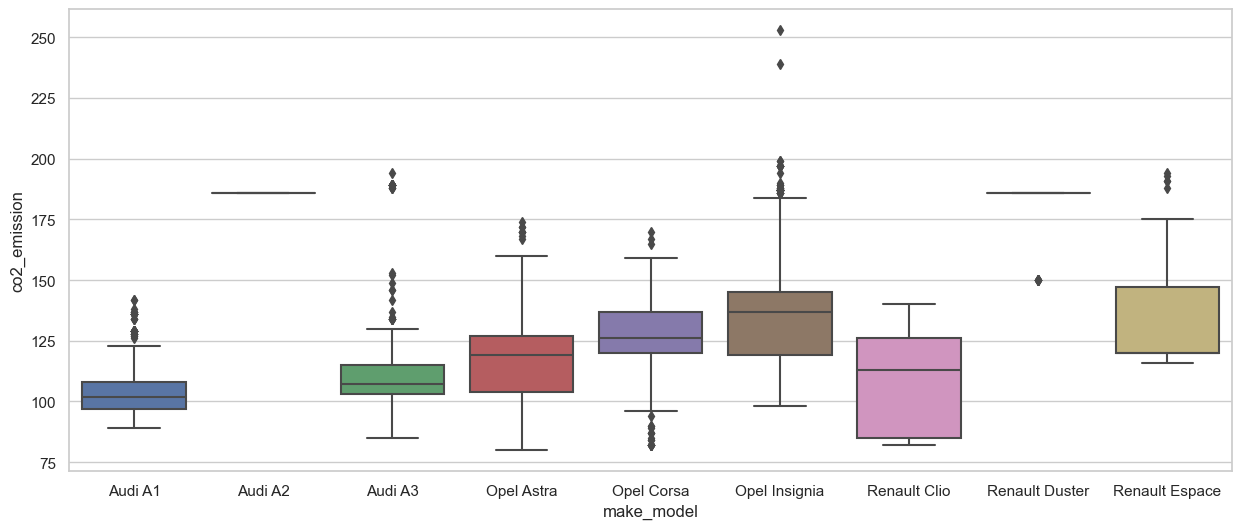

In [76]:
plt.figure(figsize=(15,6))
sns.boxplot(y='co2_emission',data=df, x='make_model');

In [77]:
# gears

In [78]:
df.gears.value_counts()

6.0     8614
5.0     4253
7.0     2810
8.0      224
9.0        6
1.0        2
3.0        2
4.0        2
2.0        1
50.0       1
Name: gears, dtype: int64

In [79]:
df.loc[df.gears==50,'gears'] = 5

In [80]:
df.loc[df.gears<5,'gears'] = 5

In [81]:
df.columns

Index(['make_model', 'body_type', 'price', 'vat', 'km', 'hp', 'type',
       'inspection_new', 'warranty', 'body_color', 'paint_type', 'nr_of_doors',
       'nr_of_seats', 'gearing_type', 'displacement', 'cylinders', 'weight',
       'drive_chain', 'fuel', 'co2_emission', 'emission_class',
       'comfort_and_convenience', 'entertainment_and_media', 'extras',
       'safety_and_security', 'gears', 'registration_year', 'age',
       'upholstery_type', 'cons_comb', 'prev_owner'],
      dtype='object')

In [82]:
# cons_comb

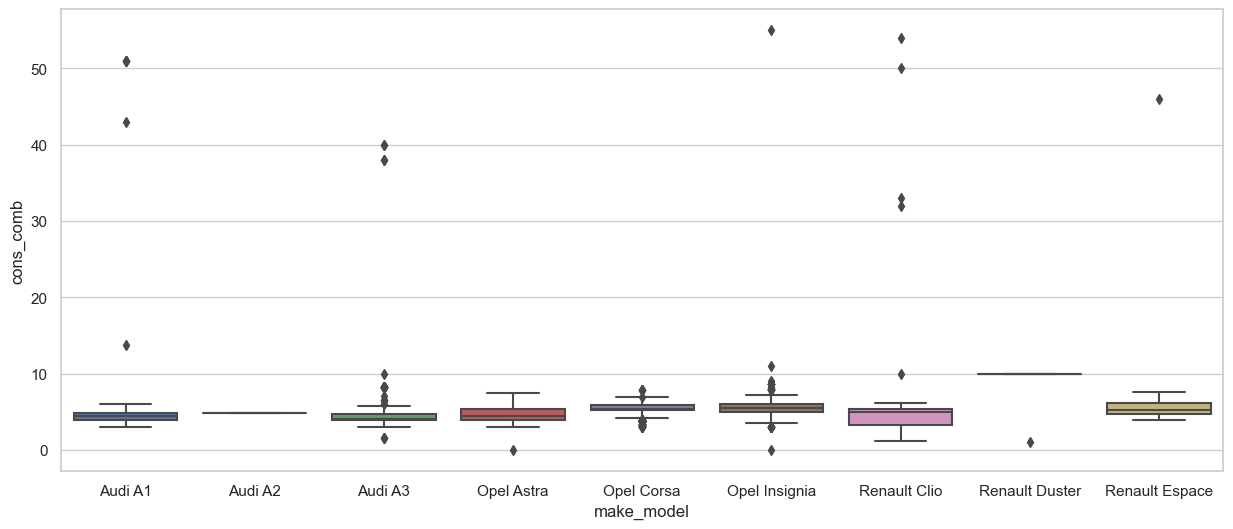

In [83]:
plt.figure(figsize=(15,6))
sns.boxplot(y='cons_comb',data=df, x='make_model');

In [84]:
df.loc[(df['cons_comb']>20 ),'cons_comb'] = np.nan

In [85]:
df.loc[(df['cons_comb']<3 ),'cons_comb'] = np.nan

In [86]:
mode_Cons= df.groupby(['co2_emission'])['cons_comb']\
              .transform(lambda x: x.mode()[0] if list(x.mode()) != [] else np.nan)

In [87]:
df['cons_comb'] = df['cons_comb'].fillna(mode_Cons)

In [88]:
mode_Cons1= df.groupby(['displacement'])['cons_comb']\
              .transform(lambda x: x.mode()[0] if list(x.mode()) != [] else np.nan)

In [89]:
df['cons_comb'] = df['cons_comb'].fillna(mode_Cons1)

In [90]:
mode_Cons2= df.groupby(['make_model'])['cons_comb']\
              .transform(lambda x: x.mode()[0] if list(x.mode()) != [] else np.nan)

In [91]:
df['cons_comb'] = df['cons_comb'].fillna(mode_Cons2)

In [92]:
df['cons_comb'].isnull().sum()

0

In [93]:
# type

In [94]:
df[(df.type == 'New') & (df['km']>10000)]

,make_model,body_type,price,vat,km,hp,type,inspection_new,warranty,body_color,...,comfort_and_convenience,entertainment_and_media,extras,safety_and_security,gears,registration_year,age,upholstery_type,cons_comb,prev_owner
15503,Renault Espace,Van,32498,VAT deductible,18035.130067,118.0,New,No,24.0,White,...,"'Air conditioning', 'Automatic climate control...",'On-board computer',NaN,"ABS,Central door lock,Electronic stability con...",6.0,2018.0,1.0,Full leather,5.4,1.0


In [95]:
df[(df.km > 1000) & (df.type == 'New')]

,make_model,body_type,price,vat,km,hp,type,inspection_new,warranty,body_color,...,comfort_and_convenience,entertainment_and_media,extras,safety_and_security,gears,registration_year,age,upholstery_type,cons_comb,prev_owner
743,Audi A1,Sedans,25900,VAT undeductible,1647.362609,85.0,New,No,0.0,Black,...,"'Air conditioning', 'Automatic climate control...","'Bluetooth', 'CD player', 'Digital radio', 'Ha...","Alloy wheels,Sport suspension,Touch screen,Tun...","ABS,Alarm system,Central door lock,Central doo...",7.0,2019.0,0.0,Cloth,4.8,1.0
869,Audi A1,Sedans,21300,VAT deductible,1647.362609,85.0,New,No,24.0,White,...,"'Air conditioning', 'Power windows'",'Radio',Alloy wheels,"ABS,Central door lock,Driver-side airbag,Elect...",7.0,2019.0,0.0,NaN,4.4,1.0
946,Audi A1,Compact,21406,VAT undeductible,1647.362609,110.0,New,No,0.0,Black,...,NaN,NaN,NaN,NaN,7.0,2019.0,0.0,NaN,5.0,1.0
977,Audi A1,Compact,21200,VAT deductible,1647.362609,85.0,New,No,110.0,White,...,"'Air conditioning', 'Electrical side mirrors',...","'Bluetooth', 'Hands-free equipment', 'Radio', ...",Alloy wheels,"ABS,Central door lock,Daytime running lights,D...",7.0,2019.0,0.0,Cloth,4.8,1.0
980,Audi A1,Compact,21100,VAT undeductible,1647.362609,85.0,New,No,0.0,Yellow,...,"'Air conditioning', 'Heads-up display', 'Power...",'Radio',Alloy wheels,"ABS,Alarm system,Central door lock,Driver-side...",6.0,2019.0,0.0,NaN,4.2,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15888,Renault Espace,Van,47990,VAT deductible,1647.362609,165.0,New,No,0.0,Brown,...,"'Air conditioning', 'Automatic climate control...",NaN,"Alloy wheels,Touch screen","ABS,Daytime running lights,Driver-side airbag,...",7.0,2019.0,0.0,Full leather,6.8,1.0
15890,Renault Espace,Station wagon,42490,VAT deductible,1647.362609,147.0,New,No,0.0,Black,...,"'Air conditioning', 'Armrest', 'Automatic clim...","'Bluetooth', 'Hands-free equipment', 'On-board...","Alloy wheels,Touch screen","ABS,Blind spot monitor,Central door lock,Dayti...",6.0,2019.0,0.0,Cloth,5.7,1.0
15902,Renault Espace,Sedans,41043,VAT deductible,1647.362609,147.0,New,No,0.0,Black,...,"'Air conditioning', 'Armrest', 'Automatic clim...","'Bluetooth', 'Digital radio', 'Hands-free equi...","Alloy wheels,Roof rack,Touch screen,Voice Control","ABS,Blind spot monitor,Central door lock,Dayti...",6.0,2019.0,0.0,NaN,5.3,1.0
15912,Renault Espace,Van,39950,VAT deductible,1647.362609,147.0,New,No,24.0,Black,...,"'Air conditioning', 'Automatic climate control...","'Bluetooth', 'Digital radio', 'Hands-free equi...","Alloy wheels,Touch screen","ABS,Central door lock,Central door lock with r...",6.0,2019.0,0.0,NaN,5.3,1.0


In [96]:
df.loc[df[(df.age > 0) & (df.type == 'New')].index, 'type'] = 'Used'

In [97]:
df.shape

(15915, 31)

In [98]:
df.to_csv("../data/processed/outlier_cleaned_data.csv", index=False)